# FinGuard — Model Training & Evaluation

This notebook develops and evaluates the primary fraud detection model
for FinGuard.

Models are evaluated using a temporal holdout set to simulate deployment
on future transactions. Particular emphasis is placed on minority-class
performance, precision-recall trade-offs and operational false-positive
costs rather than overall accuracy.

To prevent information leakage, the production feature set excludes
variables that would only become available after a transaction has been
processed.

In [3]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/raw/paysim.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df["hour"] = (df["step"] - 1) % 24
df["day"] = (df["step"] - 1) // 24

In [5]:
df["amount_to_orig_balance"] = (
    df["amount"] / (df["oldbalanceOrg"] + 1)
)

In [6]:
df["orig_balance_zero"] = (
    df["oldbalanceOrg"] == 0
).astype(int)

df["amount_equals_orig_balance"] = (
    np.isclose(
        df["amount"],
        df["oldbalanceOrg"],
        rtol=1e-5,
        atol=1e-2
    )
).astype(int)

In [7]:
df = pd.get_dummies(
    df,
    columns=["type"],
    prefix="type",
    dtype=int
)

In [8]:
feature_columns = [
    "step",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "amount_to_orig_balance",
    "orig_balance_zero",
    "amount_equals_orig_balance",
    "hour",
    "day",
    "type_CASH_IN",
    "type_CASH_OUT",
    "type_DEBIT",
    "type_PAYMENT",
    "type_TRANSFER"
]

X = df[feature_columns]
y = df["isFraud"]

print(X.shape)
X.head()

(6362620, 14)


,step,amount,oldbalanceOrg,oldbalanceDest,amount_to_orig_balance,orig_balance_zero,amount_equals_orig_balance,hour,day,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,0.0,0.057834,0,0,0,0,0,0,0,1,0
1,1,1864.28,21249.0,0.0,0.087731,0,0,0,0,0,0,0,1,0
2,1,181.00,181.0,0.0,0.994505,0,1,0,0,0,0,0,0,1
3,1,181.00,181.0,21182.0,0.994505,0,1,0,0,0,1,0,0,0
4,1,11668.14,41554.0,0.0,0.280788,0,0,0,0,0,0,0,1,0


In [9]:
split_step = int(df["step"].max() * 0.8)

train_mask = df["step"] <= split_step
test_mask = df["step"] > split_step

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Split step:", split_step)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain fraud:")
print(y_train.value_counts())

print("\nTest fraud:")
print(y_test.value_counts())

Split step: 594
X_train: (6239040, 14)
X_test: (123580, 14)

Train fraud:
isFraud
0    6232481
1       6559
Name: count, dtype: int64

Test fraud:
isFraud
0    121926
1      1654
Name: count, dtype: int64


In [10]:
from xgboost import XGBClassifier

In [11]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Legitimate:", negative_count)
print("Fraud:", positive_count)
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Legitimate: 6232481
Fraud: 6559
scale_pos_weight: 950.22


In [12]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [13]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(
    X_test
)[:, 1]

In [14]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

print(
    classification_report(
        y_test,
        y_pred_xgb,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000    121926
           1     1.0000    0.9994    0.9997      1654

    accuracy                         1.0000    123580
   macro avg     1.0000    0.9997    0.9998    123580
weighted avg     1.0000    1.0000    1.0000    123580



In [15]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

cm_xgb

array([[121926,      0],
       [     1,   1653]])

In [16]:
pr_auc_xgb = average_precision_score(
    y_test,
    y_prob_xgb
)

roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print(f"Fraud Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Fraud Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"Fraud F1:        {f1_score(y_test, y_pred_xgb):.4f}")
print(f"PR-AUC:          {pr_auc_xgb:.4f}")
print(f"ROC-AUC:         {roc_auc_xgb:.4f}")

Fraud Precision: 1.0000
Fraud Recall:    0.9994
Fraud F1:        0.9997
PR-AUC:          1.0000
ROC-AUC:         1.0000


In [17]:
cm_xgb

array([[121926,      0],
       [     1,   1653]])

In [18]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
6,amount_equals_orig_balance,0.893045
4,amount_to_orig_balance,0.065253
1,amount,0.008954
2,oldbalanceOrg,0.006402
13,type_TRANSFER,0.005296
12,type_PAYMENT,0.003832
10,type_CASH_OUT,0.003586
8,day,0.002796
9,type_CASH_IN,0.002780
3,oldbalanceDest,0.002520


In [19]:
df.groupby("isFraud")[
    [
        "amount",
        "oldbalanceOrg",
        "oldbalanceDest",
        "amount_to_orig_balance",
        "orig_balance_zero",
        "amount_equals_orig_balance",
        "hour",
        "day"
    ]
].median()

,amount,oldbalanceOrg,oldbalanceDest,amount_to_orig_balance,orig_balance_zero,amount_equals_orig_balance,hour,day
isFraud,,,,,,,,
0,74684.72,14069.00,133311.8,6.511566,0.0,0.0,15.0,9.0
1,441423.44,438983.45,0.0,0.999998,0.0,1.0,11.0,15.0


In [20]:
pd.crosstab(
    df["amount_equals_orig_balance"],
    df["isFraud"],
    margins=True
)

isFraud,0,1,All
amount_equals_orig_balance,,,
0,6354398,179,6354577
1,9,8034,8043
All,6354407,8213,6362620


In [21]:
df.groupby(
    "amount_equals_orig_balance"
)["isFraud"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
amount_equals_orig_balance,,,
0,6354577,179,0.000028
1,8043,8034,0.998881


In [22]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

importance

,feature,importance
6,amount_equals_orig_balance,0.893045
4,amount_to_orig_balance,0.065253
1,amount,0.008954
2,oldbalanceOrg,0.006402
13,type_TRANSFER,0.005296
12,type_PAYMENT,0.003832
10,type_CASH_OUT,0.003586
8,day,0.002796
9,type_CASH_IN,0.002780
3,oldbalanceDest,0.002520


## Feature Ablation: Synthetic Fraud Signature

The initial XGBoost model achieved near-perfect performance. Further
analysis showed that `amount_equals_orig_balance` dominated feature
importance.

Within the PaySim dataset, 8,034 of the 8,043 transactions for which
the transaction amount approximately equals the origin account balance
are fraudulent. This creates an unusually strong synthetic fraud
signature.

Although this feature is derived entirely from information available
before transaction execution and therefore does not constitute
post-transaction leakage, its near-perfect relationship with the target
may not generalise to real financial transaction data.

An ablation experiment is therefore performed to evaluate model
performance without this engineered shortcut.

In [23]:
ablation_features = [
    col for col in feature_columns
    if col != "amount_equals_orig_balance"
]

X_ablation = df[ablation_features]

X_train_ablation = X_ablation.loc[train_mask]
X_test_ablation = X_ablation.loc[test_mask]

print("Features:", len(ablation_features))
print(ablation_features)

Features: 13
['step', 'amount', 'oldbalanceOrg', 'oldbalanceDest', 'amount_to_orig_balance', 'orig_balance_zero', 'hour', 'day', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [24]:
xgb_ablation_1 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

xgb_ablation_1.fit(
    X_train_ablation,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [25]:
y_pred_ablation_1 = xgb_ablation_1.predict(
    X_test_ablation
)

y_prob_ablation_1 = xgb_ablation_1.predict_proba(
    X_test_ablation
)[:, 1]

In [26]:
print(
    classification_report(
        y_test,
        y_pred_ablation_1,
        digits=4
    )
)

cm_ablation_1 = confusion_matrix(
    y_test,
    y_pred_ablation_1
)

print("\nConfusion Matrix:")
print(cm_ablation_1)

print(
    "\nFraud Precision:",
    f"{precision_score(y_test, y_pred_ablation_1):.4f}"
)

print(
    "Fraud Recall:",
    f"{recall_score(y_test, y_pred_ablation_1):.4f}"
)

print(
    "Fraud F1:",
    f"{f1_score(y_test, y_pred_ablation_1):.4f}"
)

print(
    "PR-AUC:",
    f"{average_precision_score(y_test, y_prob_ablation_1):.4f}"
)

print(
    "ROC-AUC:",
    f"{roc_auc_score(y_test, y_prob_ablation_1):.4f}"
)

              precision    recall  f1-score   support

           0     1.0000    0.9988    0.9994    121926
           1     0.9163    0.9994    0.9560      1654

    accuracy                         0.9988    123580
   macro avg     0.9581    0.9991    0.9777    123580
weighted avg     0.9989    0.9988    0.9988    123580


Confusion Matrix:
[[121775    151]
 [     1   1653]]

Fraud Precision: 0.9163
Fraud Recall: 0.9994
Fraud F1: 0.9560
PR-AUC: 0.9938
ROC-AUC: 0.9999


In [27]:
importance_ablation_1 = pd.DataFrame({
    "feature": X_train_ablation.columns,
    "importance": xgb_ablation_1.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

importance_ablation_1

,feature,importance
4,amount_to_orig_balance,0.468763
8,type_CASH_IN,0.237809
11,type_PAYMENT,0.069016
2,oldbalanceOrg,0.055051
12,type_TRANSFER,0.047643
5,orig_balance_zero,0.039664
1,amount,0.038828
9,type_CASH_OUT,0.017829
6,hour,0.011618
3,oldbalanceDest,0.006240


In [28]:
ablation_2_features = [
    col for col in feature_columns
    if col not in [
        "amount_equals_orig_balance",
        "amount_to_orig_balance"
    ]
]

X_ablation_2 = df[ablation_2_features]

X_train_ablation_2 = X_ablation_2.loc[train_mask]
X_test_ablation_2 = X_ablation_2.loc[test_mask]

print(ablation_2_features)

['step', 'amount', 'oldbalanceOrg', 'oldbalanceDest', 'orig_balance_zero', 'hour', 'day', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [29]:
xgb_ablation_2 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

xgb_ablation_2.fit(
    X_train_ablation_2,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [30]:
y_pred_ablation_2 = xgb_ablation_2.predict(
    X_test_ablation_2
)

y_prob_ablation_2 = xgb_ablation_2.predict_proba(
    X_test_ablation_2
)[:, 1]

In [31]:
print(classification_report(
    y_test,
    y_pred_ablation_2,
    digits=4
))

cm_ablation_2 = confusion_matrix(
    y_test,
    y_pred_ablation_2
)

print("\nConfusion Matrix:")
print(cm_ablation_2)

print(f"\nFraud Precision: {precision_score(y_test, y_pred_ablation_2):.4f}")
print(f"Fraud Recall:    {recall_score(y_test, y_pred_ablation_2):.4f}")
print(f"Fraud F1:        {f1_score(y_test, y_pred_ablation_2):.4f}")
print(f"PR-AUC:          {average_precision_score(y_test, y_prob_ablation_2):.4f}")
print(f"ROC-AUC:         {roc_auc_score(y_test, y_prob_ablation_2):.4f}")

              precision    recall  f1-score   support

           0     1.0000    0.9802    0.9900    121926
           1     0.4060    0.9970    0.5770      1654

    accuracy                         0.9804    123580
   macro avg     0.7030    0.9886    0.7835    123580
weighted avg     0.9920    0.9804    0.9845    123580


Confusion Matrix:
[[119513   2413]
 [     5   1649]]

Fraud Precision: 0.4060
Fraud Recall:    0.9970
Fraud F1:        0.5770
PR-AUC:          0.9563
ROC-AUC:         0.9991


In [32]:
importance_ablation_2 = pd.DataFrame({
    "feature": X_train_ablation_2.columns,
    "importance": xgb_ablation_2.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

importance_ablation_2

,feature,importance
7,type_CASH_IN,0.267981
10,type_PAYMENT,0.250691
8,type_CASH_OUT,0.116984
4,orig_balance_zero,0.091659
11,type_TRANSFER,0.086025
2,oldbalanceOrg,0.060948
1,amount,0.050558
5,hour,0.029484
3,oldbalanceDest,0.027262
0,step,0.008461


## Decision Threshold Optimisation

The default classification threshold of 0.50 does not necessarily
represent the optimal operating point for a fraud detection system.

Lower thresholds generally increase fraud detection but also increase
false-positive alerts, while higher thresholds reduce false positives
at the cost of potentially missing additional fraudulent transactions.

FinGuard therefore evaluates multiple decision thresholds to examine
the operational trade-off between fraud recall and legitimate
transactions incorrectly flagged for investigation.

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.96, 0.05)

threshold_results = []

for threshold in thresholds:
    predictions = (
        y_prob_ablation_2 >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            y_test,
            predictions
        ),
        "f1": f1_score(
            y_test,
            predictions
        ),
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,threshold,precision,recall,f1,false_positives,false_negatives,true_positives
0,0.05,0.177544,1.000000,0.301550,7662,0,1654
1,0.10,0.224362,1.000000,0.366497,5718,0,1654
2,0.15,0.255447,0.999395,0.406892,4818,1,1653
3,0.20,0.281863,0.998791,0.439654,4209,2,1652
4,0.25,0.307520,0.998791,0.470253,3720,2,1652
5,0.30,0.326418,0.998791,0.492033,3409,2,1652
6,0.35,0.347213,0.998186,0.515213,3104,3,1651
7,0.40,0.364480,0.997582,0.533894,2877,4,1650
8,0.45,0.384562,0.996977,0.555032,2639,5,1649
9,0.50,0.405958,0.996977,0.576977,2413,5,1649


In [35]:
best_f1_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

best_f1_row

threshold             0.950000
precision             0.851936
recall                0.904474
f1                    0.877419
false_positives     260.000000
false_negatives     158.000000
true_positives     1496.000000
Name: 18, dtype: float64

In [36]:
high_recall_candidates = threshold_df[
    threshold_df["recall"] >= 0.95
]

high_recall_candidates.sort_values(
    "false_positives"
).head(10)

,threshold,precision,recall,f1,false_positives,false_negatives,true_positives
16,0.85,0.668222,0.952237,0.785340,782,79,1575
15,0.80,0.601723,0.970979,0.743003,1063,48,1606
14,0.75,0.558379,0.983071,0.712221,1286,28,1626
13,0.70,0.521365,0.988513,0.682672,1501,19,1635
12,0.65,0.487240,0.992745,0.653662,1728,12,1642
11,0.60,0.457754,0.995768,0.627190,1951,7,1647
10,0.55,0.429614,0.996372,0.600364,2188,6,1648
9,0.50,0.405958,0.996977,0.576977,2413,5,1649
8,0.45,0.384562,0.996977,0.555032,2639,5,1649
7,0.40,0.364480,0.997582,0.533894,2877,4,1650


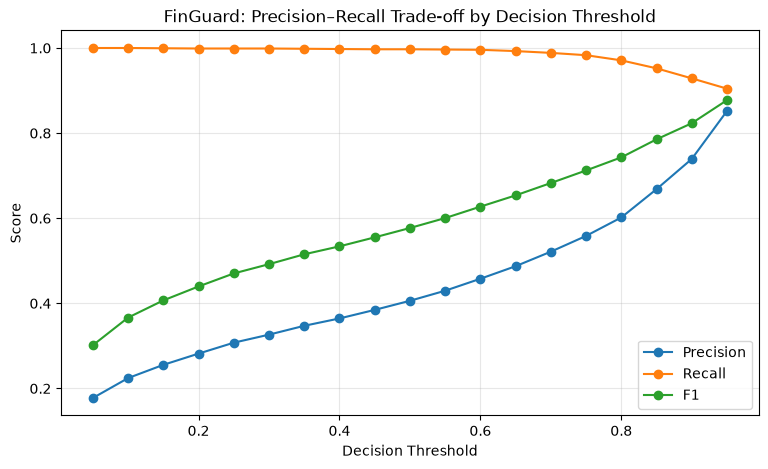

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("FinGuard: Precision–Recall Trade-off by Decision Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Cost-Sensitive Threshold Analysis

Classification metrics alone do not capture the financial consequences
of fraud detection decisions.

A false negative may expose the institution to the value of a fraudulent
transaction, while a false positive can create operational costs through
manual investigation and customer friction.

FinGuard therefore evaluates thresholds using both classification
performance and estimated financial exposure.

The analysis uses transaction amount as a proxy for potential exposure
from missed fraud and explicitly states hypothetical operational costs
for false-positive investigations.

In [38]:
test_amounts = df.loc[test_mask, "amount"].reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

threshold_cost_results = []

for threshold in thresholds:

    predictions = (
        y_prob_ablation_2 >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_reset,
        predictions
    ).ravel()

    missed_fraud_mask = (
        (y_test_reset == 1) &
        (predictions == 0)
    )

    detected_fraud_mask = (
        (y_test_reset == 1) &
        (predictions == 1)
    )

    missed_fraud_value = test_amounts[
        missed_fraud_mask
    ].sum()

    detected_fraud_value = test_amounts[
        detected_fraud_mask
    ].sum()

    threshold_cost_results.append({
        "threshold": threshold,
        "false_positives": fp,
        "false_negatives": fn,
        "missed_fraud_value": missed_fraud_value,
        "detected_fraud_value": detected_fraud_value
    })

cost_df = pd.DataFrame(threshold_cost_results)

cost_df

,threshold,false_positives,false_negatives,missed_fraud_value,detected_fraud_value
0,0.05,7662,0,0.00,2.722435e+09
1,0.10,5718,0,0.00,2.722435e+09
2,0.15,4818,1,5271.46,2.722429e+09
3,0.20,4209,2,19631.58,2.722415e+09
4,0.25,3720,2,19631.58,2.722415e+09
5,0.30,3409,2,19631.58,2.722415e+09
6,0.35,3104,3,19631.58,2.722415e+09
7,0.40,2877,4,40990.38,2.722394e+09
8,0.45,2639,5,40990.38,2.722394e+09
9,0.50,2413,5,40990.38,2.722394e+09


In [39]:
total_fraud_value = test_amounts[
    y_test_reset == 1
].sum()

cost_df["fraud_value_detection_rate"] = (
    cost_df["detected_fraud_value"]
    / total_fraud_value
)

cost_df[
    [
        "threshold",
        "false_positives",
        "false_negatives",
        "missed_fraud_value",
        "fraud_value_detection_rate"
    ]
]

,threshold,false_positives,false_negatives,missed_fraud_value,fraud_value_detection_rate
0,0.05,7662,0,0.00,1.000000
1,0.10,5718,0,0.00,1.000000
2,0.15,4818,1,5271.46,0.999998
3,0.20,4209,2,19631.58,0.999993
4,0.25,3720,2,19631.58,0.999993
5,0.30,3409,2,19631.58,0.999993
6,0.35,3104,3,19631.58,0.999993
7,0.40,2877,4,40990.38,0.999985
8,0.45,2639,5,40990.38,0.999985
9,0.50,2413,5,40990.38,0.999985


In [ ]:
# hypothetical cost of reviewing false positives
FALSE_POSITIVE_REVIEW_COST = 10

cost_df["false_positive_cost"] = (
    cost_df["false_positives"]
    * FALSE_POSITIVE_REVIEW_COST
)

cost_df["estimated_total_cost"] = (
    cost_df["missed_fraud_value"]
    + cost_df["false_positive_cost"]
)

In [41]:
cost_df[
    [
        "threshold",
        "false_positives",
        "false_negatives",
        "missed_fraud_value",
        "false_positive_cost",
        "estimated_total_cost"
    ]
].sort_values(
    "estimated_total_cost"
)

,threshold,false_positives,false_negatives,missed_fraud_value,false_positive_cost,estimated_total_cost
6,0.35,3104,3,19631.58,31040,50671.58
2,0.15,4818,1,5271.46,48180,53451.46
5,0.30,3409,2,19631.58,34090,53721.58
4,0.25,3720,2,19631.58,37200,56831.58
1,0.10,5718,0,0.00,57180,57180.00
3,0.20,4209,2,19631.58,42090,61721.58
9,0.50,2413,5,40990.38,24130,65120.38
8,0.45,2639,5,40990.38,26390,67380.38
7,0.40,2877,4,40990.38,28770,69760.38
10,0.55,2188,6,52145.83,21880,74025.83


In [42]:
total_fraud_value = test_amounts[
    y_test_reset == 1
].sum()

print(f"Total fraud value: {total_fraud_value:,.2f}")

fraud_amounts = test_amounts[
    y_test_reset == 1
]

print("\nFraud amount statistics:")
print(fraud_amounts.describe())

Total fraud value: 2,722,434,569.36

Fraud amount statistics:
count    1.654000e+03
mean     1.645970e+06
std      2.737189e+06
min      0.000000e+00
25%      1.191843e+05
50%      4.196206e+05
75%      1.555182e+06
max      1.000000e+07
Name: amount, dtype: float64


## Operational Cost Sensitivity Analysis

The true operational cost of investigating a false-positive fraud alert
is institution-specific and is not provided by PaySim.

Rather than assuming a single cost value represents a real financial
institution, FinGuard performs a sensitivity analysis across several
hypothetical review-cost scenarios.

Missed fraudulent transaction value is used as a proxy for potential
fraud exposure. These results therefore represent comparative decision
scenarios rather than estimates of actual bank losses.

In [43]:
review_costs = [1, 5, 10, 25, 50, 100]

sensitivity_results = []

for review_cost in review_costs:

    temp = cost_df.copy()

    temp["false_positive_cost"] = (
        temp["false_positives"] * review_cost
    )

    temp["estimated_total_cost"] = (
        temp["missed_fraud_value"]
        + temp["false_positive_cost"]
    )

    best_row = temp.loc[
        temp["estimated_total_cost"].idxmin()
    ]

    sensitivity_results.append({
        "review_cost": review_cost,
        "optimal_threshold": best_row["threshold"],
        "false_positives": best_row["false_positives"],
        "false_negatives": best_row["false_negatives"],
        "missed_fraud_value": best_row["missed_fraud_value"],
        "estimated_total_cost": best_row["estimated_total_cost"]
    })

sensitivity_df = pd.DataFrame(
    sensitivity_results
)

sensitivity_df

,review_cost,optimal_threshold,false_positives,false_negatives,missed_fraud_value,estimated_total_cost
0,1,0.10,5718.0,0.0,0.00,5718.00
1,5,0.10,5718.0,0.0,0.00,28590.00
2,10,0.35,3104.0,3.0,19631.58,50671.58
3,25,0.35,3104.0,3.0,19631.58,97231.58
4,50,0.55,2188.0,6.0,52145.83,161545.83
5,100,0.55,2188.0,6.0,52145.83,270945.83


In [44]:
sensitivity_df = sensitivity_df.merge(
    threshold_df[
        [
            "threshold",
            "precision",
            "recall",
            "f1"
        ]
    ],
    left_on="optimal_threshold",
    right_on="threshold",
    how="left"
).drop(columns=["threshold"])

sensitivity_df

,review_cost,optimal_threshold,false_positives,false_negatives,missed_fraud_value,estimated_total_cost,precision,recall,f1
0,1,0.10,5718.0,0.0,0.00,5718.00,0.224362,1.000000,0.366497
1,5,0.10,5718.0,0.0,0.00,28590.00,0.224362,1.000000,0.366497
2,10,0.35,3104.0,3.0,19631.58,50671.58,0.347213,0.998186,0.515213
3,25,0.35,3104.0,3.0,19631.58,97231.58,0.347213,0.998186,0.515213
4,50,0.55,2188.0,6.0,52145.83,161545.83,0.429614,0.996372,0.600364
5,100,0.55,2188.0,6.0,52145.83,270945.83,0.429614,0.996372,0.600364


## Model Selection & Deployment Strategy

The experiments demonstrate that the optimal fraud decision threshold
depends on the operational cost associated with false-positive
investigations and the financial exposure associated with missed fraud.

Rather than embedding a fixed 0.50 classification threshold into the
model, FinGuard separates predictive modelling from risk policy.

The trained model produces a continuous fraud risk score. A configurable
decision threshold can then be applied according to the institution's
risk appetite and operational constraints.

Feature ablation also demonstrated that near-perfect initial performance
was strongly influenced by synthetic patterns within the PaySim dataset.
The deployment model therefore excludes the engineered
`amount_equals_orig_balance` and `amount_to_orig_balance` features to
provide a more conservative evaluation of generalisation.

All monetary cost scenarios presented here are hypothetical and are
used for comparative analysis rather than as estimates of real banking
costs.

In [45]:
from pathlib import Path

ARTIFACT_DIR = Path("../artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

MODEL_PATH = ARTIFACT_DIR / "finguard_xgb.json"

xgb_ablation_2.save_model(MODEL_PATH)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: ../artifacts/finguard_xgb.json


In [47]:
import json

metadata = {
    "model_name": "FinGuard XGBoost Fraud Detector",
    "model_version": "1.0.0",
    "model_type": "XGBClassifier",

    "features": ablation_2_features,

    "target": "isFraud",

    "training_split": {
        "strategy": "temporal",
        "train_steps": f"1-{split_step}",
        "test_steps": f"{split_step + 1}-{df['step'].max()}"
    },

    "evaluation": {
        "pr_auc": float(
            average_precision_score(
                y_test,
                y_prob_ablation_2
            )
        ),
        "roc_auc": float(
            roc_auc_score(
                y_test,
                y_prob_ablation_2
            )
        )
    },

    "default_policy_threshold": 0.85,

    "threshold_note": (
        "Threshold is configurable and should be selected "
        "according to operational risk policy."
    )
}

METADATA_PATH = ARTIFACT_DIR / "model_metadata.json"

with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"Metadata saved to: {METADATA_PATH}")

Metadata saved to: ../artifacts/model_metadata.json


In [48]:
from xgboost import XGBClassifier

loaded_model = XGBClassifier()

loaded_model.load_model(
    "../artifacts/finguard_xgb.json"
)

loaded_probabilities = loaded_model.predict_proba(
    X_test_ablation_2
)[:, 1]

In [49]:
np.allclose(
    y_prob_ablation_2,
    loaded_probabilities
)

True